# 속도와 가속도 (미분)

위치 $s(t)$에 대해

$$
v(t) = s'(t), \qquad a(t) = v'(t) = s''(t)
$$

| 기호 | 의미 |
|------|------|
| $s(t)$ | 위치 (변위) |
| $v(t)$ | 속도 |
| $a(t)$ | 가속도 |

## 1. sympy로 $v$, $a$ 구하기

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

sp.init_printing()
t = sp.symbols('t', real=True)

s = 3*t**2 + 2*t + 1
v = sp.diff(s, t)
a = sp.diff(v, t)  # = diff(s, t, 2)

print("s(t) =")
display(s)
print("v(t) = s'(t) =")
display(v)
print("a(t) = v'(t) =")
display(a)

s(t) =


v(t) = s'(t) =


a(t) = v'(t) =


**sp.diff(s, t)**: <br>
=> 속도

**sp.diff(s, t, 2)**: <br>
=> 가속도 (2번 미분)

## 2. 특정 시각에서의 값

In [2]:
for t0 in [0, 1, 2, 5]:
    print(f"t={t0}: s={s.subs(t,t0)}, v={v.subs(t,t0)}, a={a.subs(t,t0)}")

t=0: s=1, v=2, a=6
t=1: s=6, v=8, a=6
t=2: s=17, v=14, a=6
t=5: s=86, v=32, a=6


## 3. 수치가 주어졌을 때 — 차분으로 근사

In [3]:
# s = t^2 를 따르는 이산 데이터
t_data = np.arange(0, 5.5, 0.5)
s_data = t_data**2

# 중심차분 / 전진차분으로 v 근사
dt = t_data[1] - t_data[0]
v_approx = np.gradient(s_data, dt)
a_approx = np.gradient(v_approx, dt)

print("t | s | v≈ | a≈ | v정확=2t | a정확=2")
for i in range(len(t_data)):
    print(f"{t_data[i]:3.1f} | {s_data[i]:5.2f} | {v_approx[i]:6.2f} | {a_approx[i]:6.2f} | {2*t_data[i]:5.2f} | 2.00")

t | s | v≈ | a≈ | v정확=2t | a정확=2
0.0 |  0.00 |   0.50 |   1.00 |  0.00 | 2.00
0.5 |  0.25 |   1.00 |   1.50 |  1.00 | 2.00
1.0 |  1.00 |   2.00 |   2.00 |  2.00 | 2.00
1.5 |  2.25 |   3.00 |   2.00 |  3.00 | 2.00
2.0 |  4.00 |   4.00 |   2.00 |  4.00 | 2.00
2.5 |  6.25 |   5.00 |   2.00 |  5.00 | 2.00
3.0 |  9.00 |   6.00 |   2.00 |  6.00 | 2.00
3.5 | 12.25 |   7.00 |   2.00 |  7.00 | 2.00
4.0 | 16.00 |   8.00 |   2.00 |  8.00 | 2.00
4.5 | 20.25 |   9.00 |   1.50 |  9.00 | 2.00
5.0 | 25.00 |   9.50 |   1.00 | 10.00 | 2.00


**np.gradient**: <br>
=> 이산 데이터의 수치 미분 (균일 간격)

## 4. 그래프: $s$, $v$, $a$

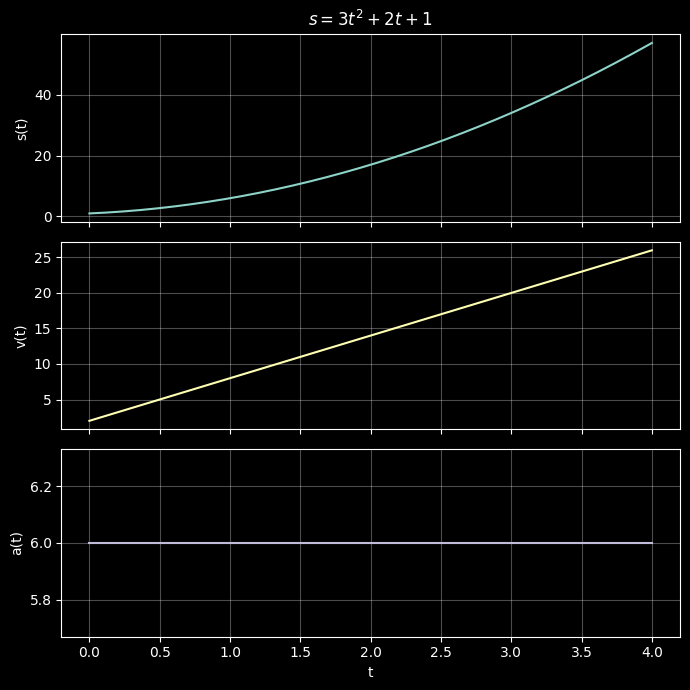

In [4]:
s_f = sp.lambdify(t, s, 'numpy')
v_f = sp.lambdify(t, v, 'numpy')
a_f = sp.lambdify(t, a, 'numpy')

tt = np.linspace(0, 4, 200)

fig, axes = plt.subplots(3, 1, figsize=(7, 7), sharex=True)
axes[0].plot(tt, s_f(tt)); axes[0].set_ylabel("s(t)"); axes[0].grid(True, alpha=0.3)
axes[1].plot(tt, v_f(tt), color="C1"); axes[1].set_ylabel("v(t)"); axes[1].grid(True, alpha=0.3)
axes[2].plot(tt, np.full_like(tt, float(a)), color="C2"); axes[2].set_ylabel("a(t)"); axes[2].set_xlabel("t")
axes[2].grid(True, alpha=0.3)
axes[0].set_title(r"$s=3t^2+2t+1$")
plt.tight_layout()
plt.show()